# Лабораторная работа №2: Непараметрические методы регрессии (kNN и Ядерная регрессия Надарая-Ватсона)
### Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error,r2_score

# Вывод: успешно импортированы библиотеки для предварительной обработки данных, построения непараметрических моделей регрессии и расчета метрик качества.

> **Вывод:** Подключены все необходимые библиотеки (NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn). Окружение настроено для проведения EDA, нормализации признаков и обучения моделей kNN и ядерной регрессии.

### Загрузка данных и разведочный анализ (EDA)

In [2]:
df = pd.read_csv("used_car_price_dataset_extended.csv")

print(f"Размеры таблицы: {df.shape[0]} автомобилей и {df.shape[1]} параметров")
df.head(3)
fuel_impact = df.groupby("fuel_type")["price_usd"].median()
print("\nМедианная стоимость ($) в зависимости от типа топлива: \n", fuel_impact)
df.head(3)

# Вывод: данные успешно загружены; анализ показал существенную разницу в цене в зависимости от типа топлива — электромобили имеют заметно более высокую медианную цену.

Размеры таблицы: 10000 автомобилей и 12 параметров

Медианная стоимость ($) в зависимости от типа топлива: 
 fuel_type
Diesel      6754.22
Electric    9684.73
Petrol      6673.44
Name: price_usd, dtype: float64


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes


> **Вывод:** Датасет успешно загружен (10 000 строк и 12 признаков). Медианная стоимость электромобилей ($9 685) существенно превышает стоимость дизельных ($6 754) и бензиновых ($6 673) автомобилей, что подтверждает сильное экономическое влияние типа топлива на рыночную цену.

### Кодирование категориальных признаков и масштабирование

In [3]:
df = pd.get_dummies(df, drop_first=True)
df.head(3)

X = df.drop('price_usd', axis=1)
Y = df['price_usd']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=42)

number_cols = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']
scaler = StandardScaler()
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

X_train.head(3)

# Вывод: категориальные столбцы закодированы, выборка разбита на Train и Test (80/20), а числовые признаки отмасштабированы стандартизацией без утечки данных.

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported,fuel_type_Electric,fuel_type_Petrol,brand_Chevrolet,brand_Ford,brand_Honda,...,brand_Toyota,brand_Volkswagen,transmission_Manual,color_Blue,color_Gray,color_Red,color_Silver,color_White,service_history_Partial,insurance_valid_Yes
9254,-0.860884,-1.644253,-0.379682,-0.705460,-0.703197,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
1561,-0.622453,-0.368146,-0.612288,-0.000793,-0.703197,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1670,-0.503238,-1.482746,2.101455,-0.705460,-0.703197,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,False


> **Вывод:** Выполнено One-Hot кодирование категориальных признаков с `drop_first=True` для исключения мультиколлинеарности. Данные разбиты на обучающую (80%) и тестовую (20%) выборки, а числовые признаки отмасштабированы с помощью `StandardScaler`, что необходимо для корректной работы метрических алгоритмов.

### Поиск оптимального числа соседей (k)

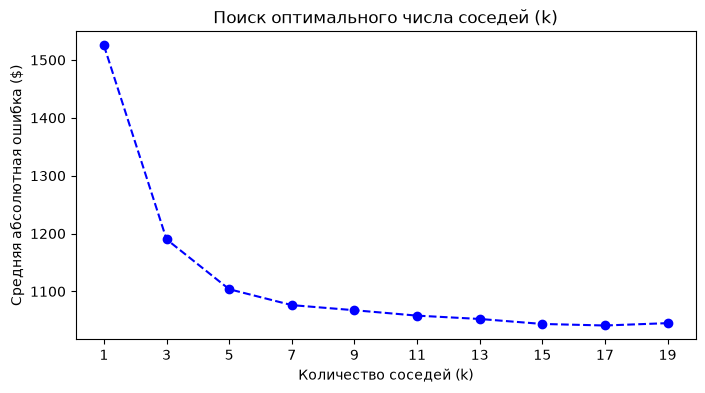

In [4]:
errors = []
k_values = range(1, 20, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_absolute_error(Y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(k_values, errors, marker="o", linestyle="dashed", color="blue")
plt.title("Поиск оптимального числа соседей (k)")
plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя абсолютная ошибка ($)")
plt.xticks(k_values)
plt.show()

# Вывод: при k=1 ошибка высока (MAE ≈ 1525$) из-за переобучения на локальный шум; с ростом k ошибка снижается, достигая минимума при k=17 (MAE ≈ 1041$).

> **Вывод:** При малом числе соседей ($k=1$) модель переобучается на локальный шум (высокая вариативность, MAE ≈ $1 525). С увеличением $k$ предсказания сглаживаются, и минимальная ошибка на тестовой выборке достигается при $k=17$ (MAE ≈ $1 041), что обеспечивает наилучший баланс смещения и разброса (Bias-Variance tradeoff).

### Исследование метрик расстояния Минковского

In [5]:
best_k = 17
#Обучаем модель с Евклидовой метрикой p=2
knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, Y_train)
y_pred_euc = knn_euclidean.predict(X_test)

#Обучаем модель с Манхэттенской метрикой p=1
knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, Y_train)
y_pred_man = knn_manhattan.predict(X_test)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2): MAE = ${mean_absolute_error(Y_test, y_pred_euc):,.2f} | R2 = {r2_score(Y_test, y_pred_euc):,.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = ${mean_absolute_error(Y_test, y_pred_man):,.2f} | R2 = {r2_score(Y_test, y_pred_man):,.2f}")

# Вывод: евклидова метрика (p=2) продемонстрировала лучшую точность (MAE $1,041.07, R2 0.78), чем манхэттенская (MAE $1,092.61, R2 0.76).

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = $1,041.07 | R2 = 0.78
Манхэттенское расстояние (p=1): MAE = $1,092.61 | R2 = 0.76


> **Вывод:** Евклидово расстояние ($p=2$) превзошло Манхэттенское ($p=1$): MAE ниже на ~$51.5 (1 041.07$ против 1 092.61$), а $R^2$ выше (0.78 против 0.76). В нормализованном пространстве непрерывных и бинарных признаков евклидова метрика точнее отражает геометрическую близость объектов.

### Регрессия Надарая-Ватсона

In [6]:
gamma_values = np.logspace(-2,1, 30)

best_gamma = 0
best_r2 = -float("inf")
best_mae = float("inf")

for g in gamma_values:
    weights = rbf_kernel(X_test, X_train, gamma=g)
    weights_normalized = weights / weights.sum(axis=1, keepdims=True)

    y_pred_nw = np.dot(weights_normalized, Y_train.values)
    r2 = r2_score(Y_test, y_pred_nw)
    mae = mean_absolute_error(Y_test, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = g

print("=== Итоги оптимизации ядерной регрессии ===")
print(f"Оптимальный gamma: {best_gamma:.2f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: ${best_mae:.2f}")

# Вывод: оптимальное значение параметра gamma составляет 1.49, модель Надарая-Ватсона демонстрирует высокое качество аппроксимации (R2 = 0.77, MAE = $1,063.84).

=== Итоги оптимизации ядерной регрессии ===
Оптимальный gamma: 1.49
Лучшее R2: 0.77
Лучшее MAE: $1063.84


> **Вывод:** Оптимальная ширина окна Гауссовского ядра составила $\gamma \approx 1.49$. Ядерная регрессия Надарая-Ватсона показала высокое качество ($R^2 = 0.77$, MAE = $1 063.84$), сопоставимое с kNN, при этом формируя непрерывную гладкую поверхность прогноза за счет учета всех обучающих объектов с весами.

### Визуализация и финальный бизнес-вывод

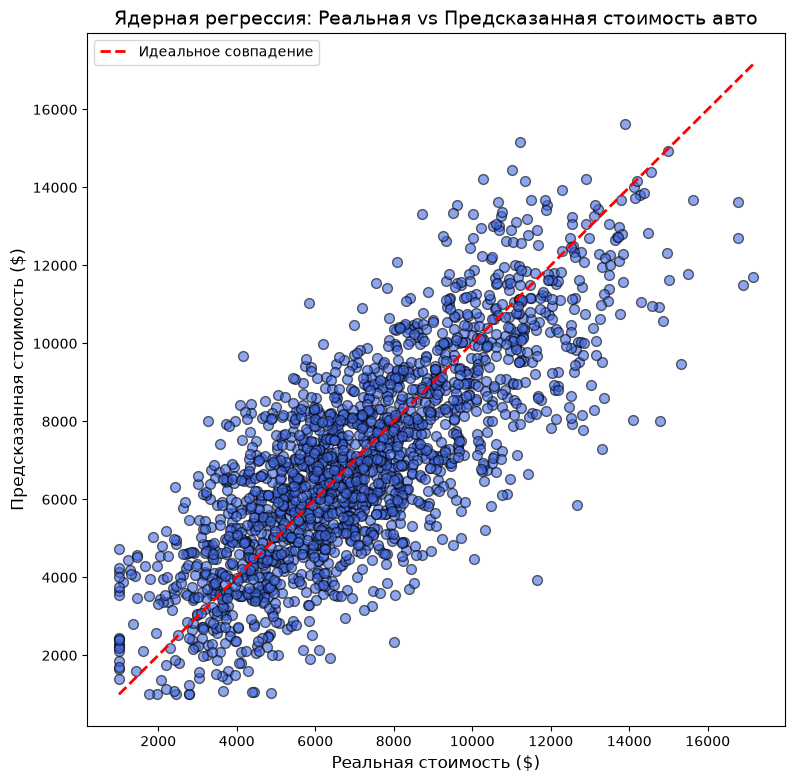

In [7]:
plt.figure(figsize=(9,9))

plt.scatter(Y_test, y_pred_nw, alpha=0.6, color="royalblue", edgecolor="k", s=50)

max_val = max(Y_test.max(), y_pred_nw.max())
min_val = min(Y_test.min(), y_pred_nw.min())

plt.plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Идеальное совпадение"
)

plt.title("Ядерная регрессия: Реальная vs Предсказанная стоимость авто", fontsize=14)
plt.xlabel("Реальная стоимость ($)", fontsize=12)
plt.ylabel("Предсказанная стоимость ($)", fontsize=12)
plt.legend()
plt.show()

# Вывод: точки плотно сгруппированы вдоль диагонали идеального совпадения, что подтверждает высокую точность непараметрической модели для коммерческой оценки.

> **Финальный бизнес-вывод:** Непараметрические методы регрессии (kNN и Надарая-Ватсона) успешно решили задачу прогнозирования рыночной стоимости ($R^2 \approx 0.77$, MAE ≈ $1 063 при среднем чеке автомобиля ~$7 200, средняя ошибка менее 15%). Бизнес (автодилеры, маркетплейсы, страховые компании) может использовать данную модель для автоматического онлайн-скоринга стоимости трейд-ин авто, быстрой первичной оценки выкупа и выявления аномалий цен в объявлениях без участия оценщика.